In [1]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from pathlib import Path

In [2]:
dataset_path = Path("../dataset")

train_dir = dataset_path / 'train'
test_dir = dataset_path / 'test'


In [3]:
## define image tranformations

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]

    )

])

In [4]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )


])

In [5]:
## create dataset

train_dataset = ImageFolder(
    train_dir,
    transform=train_transform
)

test_dataset = ImageFolder(
    test_dir,
    transform=test_transform
)

In [6]:
## check dataset size

print('Training Images :', len(train_dataset))
print('Testing Images :', len(test_dataset))

Training Images : 13898
Testing Images : 1546


In [7]:
## class names

class_names = train_dataset.classes

print(class_names)

['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


In [8]:
## create dataloader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [9]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [10]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import matplotlib.pyplot as plt

def imshow(img):
    img = img.permute(1, 2, 0).numpy()

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    img = img * std + mean
    img = img.clip(0, 1)

    plt.imshow(img)

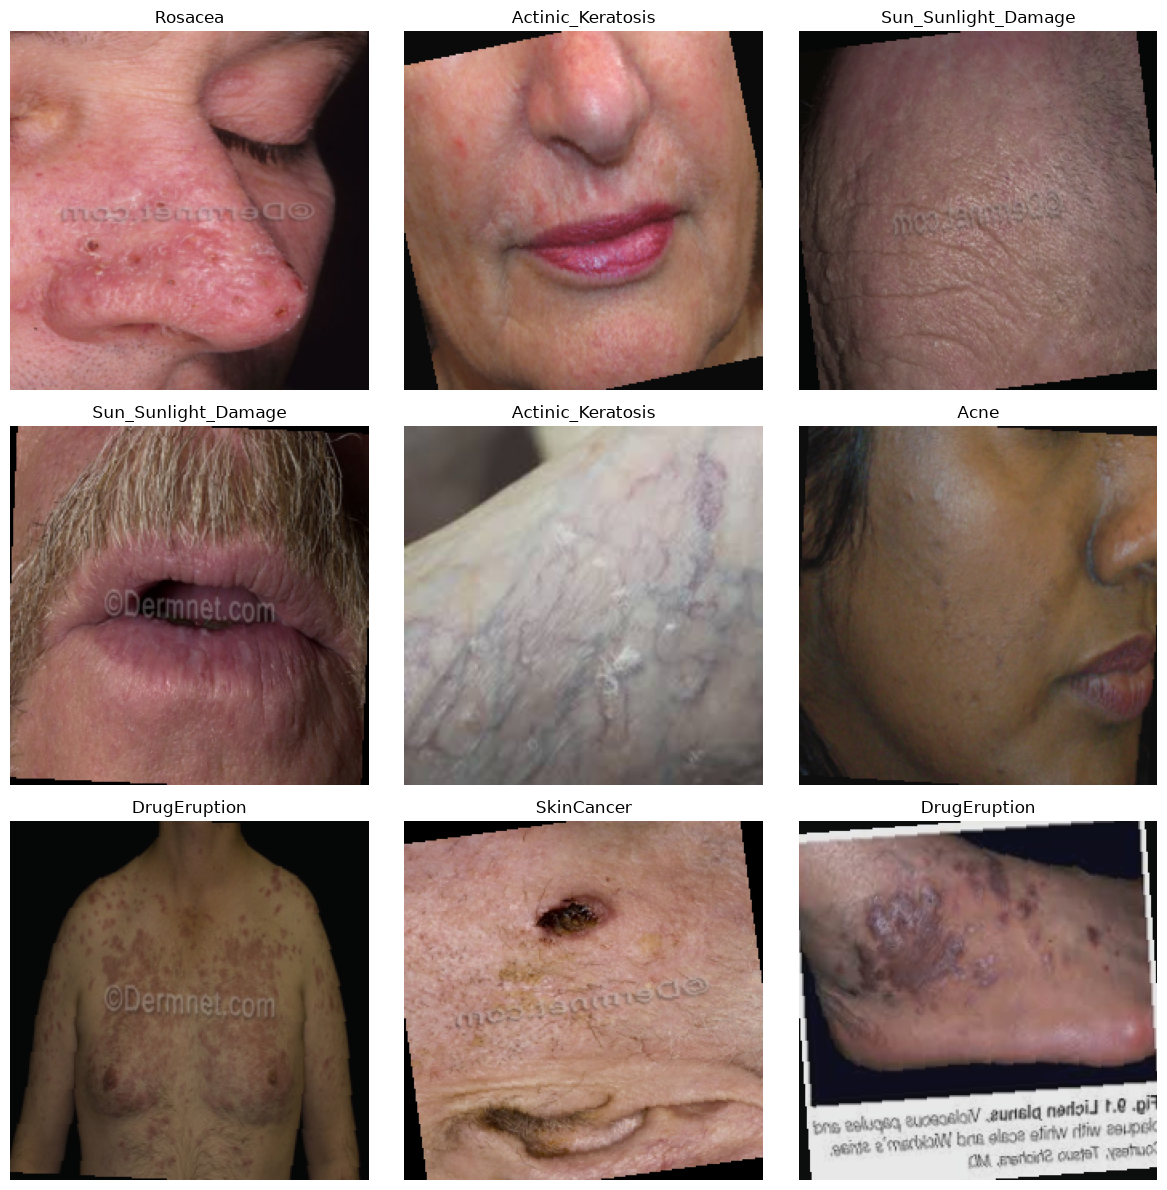

In [12]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    imshow(images[i])

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()


## MODEL TRAINING

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from tqdm import tqdm
import matplotlib.pyplot as plt

In [14]:
!pip install tqdm


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
!nvidia-smi

Fri Jun 26 16:12:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 592.27                 Driver Version: 592.27         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   49C    P8              3W /   50W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
!python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [16]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

2.11.0+cu128
True
1
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [17]:
import sys
import torch

print("Python executable:")
print(sys.executable)

print("\nTorch version:")
print(torch.__version__)

print("\nTorch location:")
print(torch.__file__)

Python executable:
c:\Users\humai\.virtualenvs\medicalCHATBOT_2.0-aymwc2xr\Scripts\python.exe

Torch version:
2.11.0+cu128

Torch location:
c:\Users\humai\.virtualenvs\medicalCHATBOT_2.0-aymwc2xr\Lib\site-packages\torch\__init__.py


In [18]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [19]:
import sys
print(sys.version)

3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


In [20]:
## select device

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [21]:
## load the pretrained EfficientNet-B0

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

In [22]:
## replace final classification layer

import torch.nn as nn

num_classes = len(class_names)

model.classifier[1] = nn.Linear(
    in_features=model.classifier[1].in_features,
    out_features=num_classes
)

In [23]:
## fine-tune the model

for param in model.parameters():
    param.requires_grad = True
    

In [24]:
## MOVE THE MODEL TO GPU

model = model.to(device)

In [25]:
## loss function

criterion = nn.CrossEntropyLoss()

In [26]:
## optimizer

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [27]:
## hyperparameters

EPOCHS = 15

In [29]:
## training loop

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        progress_bar.set_description(
            f"Epoch [{epoch+1}/{EPOCHS}]"
        )

        progress_bar.set_postfix(
            Loss=loss.item()
        )

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"\nEpoch {epoch+1}")
    print(f"Loss     : {epoch_loss:.4f}")
    print(f"Accuracy : {epoch_accuracy:.2f}%")

Epoch [1/15]: 100%|██████████| 435/435 [02:42<00:00,  2.68it/s, Loss=1.78] 



Epoch 1
Loss     : 1.4619
Accuracy : 55.00%


Epoch [2/15]: 100%|██████████| 435/435 [02:07<00:00,  3.42it/s, Loss=1.49] 



Epoch 2
Loss     : 1.1609
Accuracy : 64.56%


Epoch [3/15]: 100%|██████████| 435/435 [02:06<00:00,  3.44it/s, Loss=2.35] 


...


Epoch 13
Loss     : 0.1944
Accuracy : 93.98%


Epoch [14/15]: 100%|██████████| 435/435 [03:35<00:00,  2.02it/s, Loss=1.61]  



Epoch 14
Loss     : 0.1879
Accuracy : 94.14%


Epoch [15/15]: 100%|██████████| 435/435 [03:43<00:00,  1.95it/s, Loss=0.0677]


Epoch 15
Loss     : 0.1621
Accuracy : 94.76%


In [31]:
## save the model

torch.save(
    model.state_dict(),
    "../models/final_model.pth"
)

print("Model saved successfully!")

Model saved successfully!


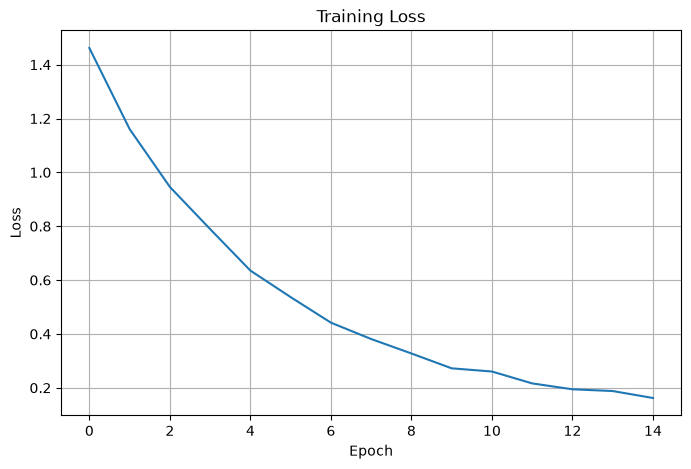

In [32]:
## plot training loss

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

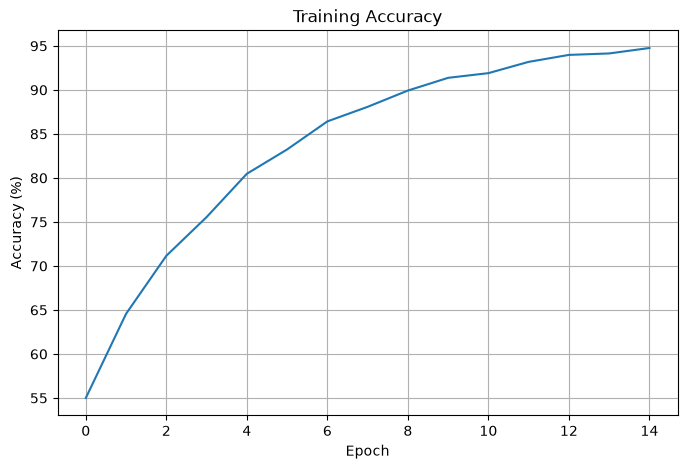

In [33]:
## plot training accuracy

plt.figure(figsize=(8,5))

plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

## Model Evaluation

In [36]:
import torch
import torch.nn as nn

from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np

In [35]:
!pip install scikit-learn


  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 527.2 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.2 MB 527.2 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.2 MB 527.2 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.2 MB 417.1 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/8.2 MB 417.1 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/8.2 MB 417.1 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/8.2 MB 


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
## load model

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(class_names)
)

model.load_state_dict(torch.load("../models/final_model.pth", map_location=device))

model.to(device)

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [38]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())


In [39]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 77.88%


In [40]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Precision: {precision:.4f}")

Precision: 0.7840


In [41]:
recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Recall: {recall:.4f}")

Recall: 0.7788


In [42]:
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7785


In [43]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                     precision    recall  f1-score   support

               Acne       0.83      0.89      0.86        65
  Actinic_Keratosis       0.82      0.78      0.80        83
      Benign_tumors       0.76      0.74      0.75       121
            Bullous       0.80      0.60      0.69        55
        Candidiasis       0.66      0.78      0.71        27
       DrugEruption       0.73      0.77      0.75        61
             Eczema       0.70      0.82      0.75       112
 Infestations_Bites       0.69      0.60      0.64        60
             Lichen       0.66      0.67      0.67        61
              Lupus       0.50      0.50      0.50        34
              Moles       0.59      0.68      0.63        40
          Psoriasis       0.84      0.75      0.79        88
            Rosacea       0.75      0.86      0.80        28
  Seborrh_Keratoses       0.72      0.84      0.77        51
         SkinCancer       0.86      0.64      0.73        77
Sun_Sunlight_Damage    

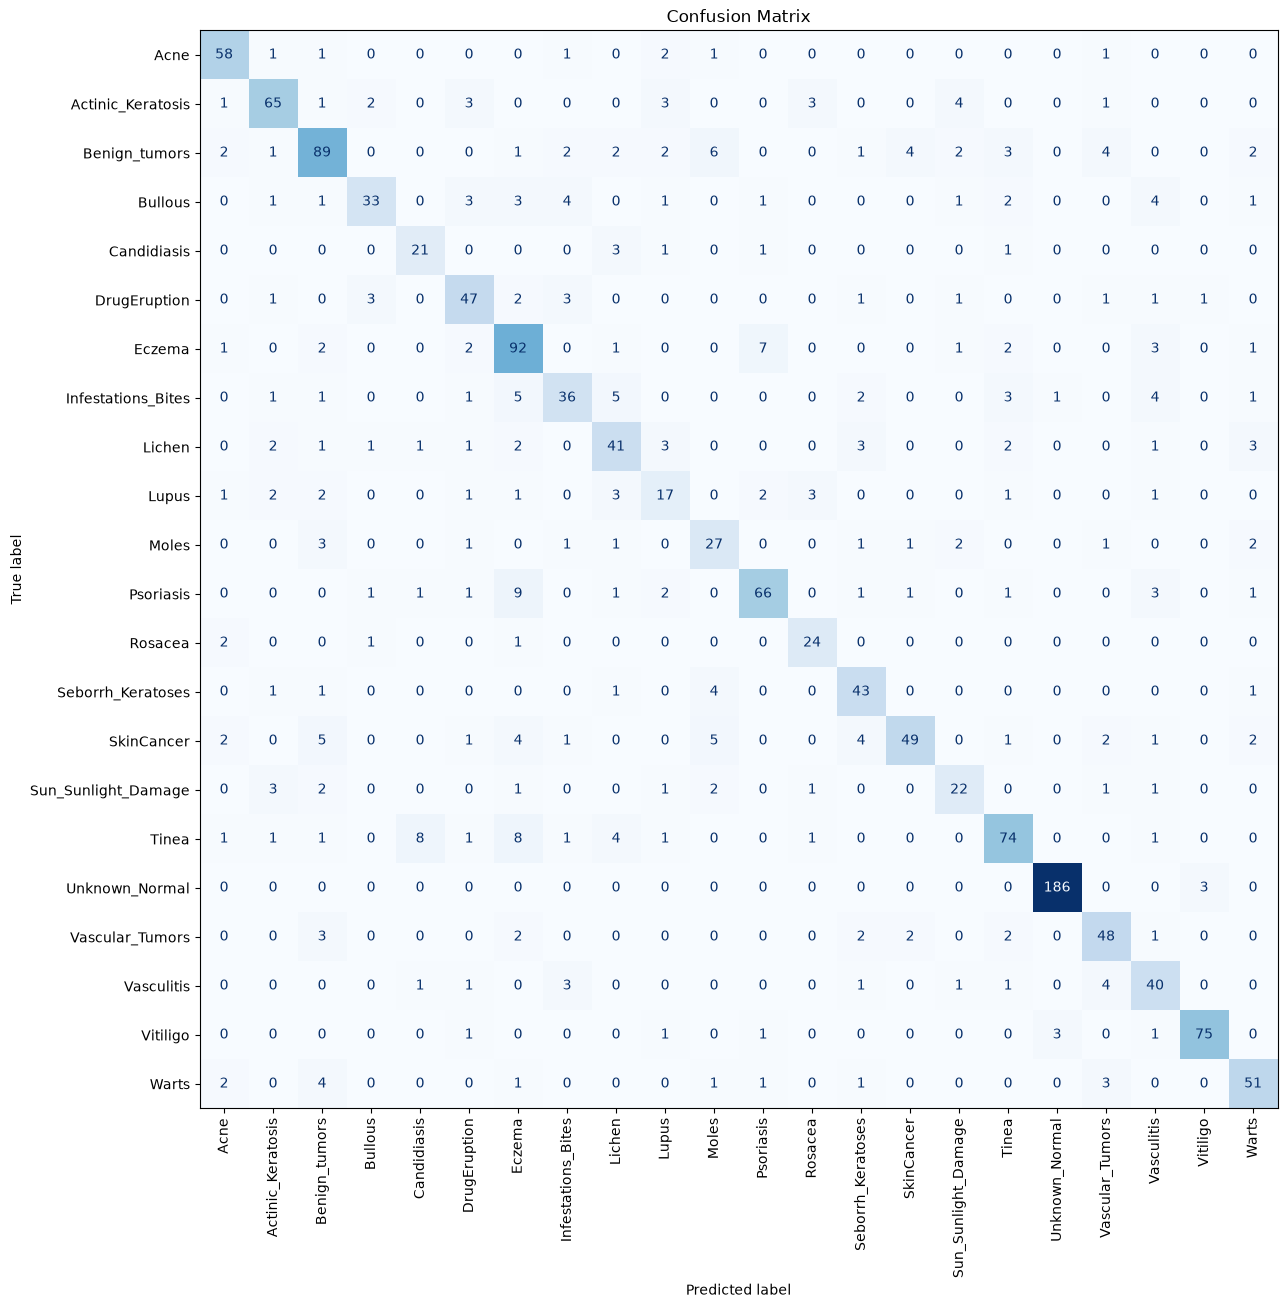

In [44]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(14,14))

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

In [45]:
print("="*50)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("="*50)

Accuracy : 77.88%
Precision: 0.7840
Recall   : 0.7788
F1 Score : 0.7785
